# Comparing DE methods in delnx

delnx provides several differential expression testing methods, each suited
to different data types and analysis scenarios:

| Method | Function | Data type | Test | Best for |
|--------|----------|-----------|------|----------|
| **ANOVA** | `dx.tl.de(method="anova")` | Log-normalized | F-test | Fast screening, continuous data |
| **Logistic regression** | `dx.tl.de(method="lr")` | Log-normalized / binary | LR test | Binary outcomes, covariate control |
| **AUROC ranking** | `dx.tl.rank_de()` | Any | Mann-Whitney U | Fast multi-group markers |
| **Negative binomial** | `dx.tl.nb_fit()` + `dx.tl.nb_test()` | Raw counts | Quasi-likelihood F | Pseudobulk, perturbation screens |

This notebook benchmarks their runtime scaling across three axes:
1. **Sample scaling** — how each method scales with increasing cell count
2. **1-vs-all marker detection** — scaling across many groups (clusters)
3. **1-vs-1 pairwise comparisons** — scaling with number of pairwise tests

In [1]:
import time

import anndata as ad
import delnx as dx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def simulate_data(n_samples, n_genes, n_groups, seed=42):
    """Simulate count data with multiple groups."""
    rng = np.random.default_rng(seed)
    counts = rng.negative_binomial(5, 0.5, size=(n_samples, n_genes)).astype(np.float64)
    adata = ad.AnnData(X=counts)
    adata.var_names = [f"gene_{i}" for i in range(n_genes)]
    adata.obs_names = [f"cell_{i}" for i in range(n_samples)]
    adata.obs["group"] = [f"g{i % n_groups}" for i in range(n_samples)]
    # Log-normalized layer for anova/lr
    adata.layers["counts"] = counts.copy()
    adata.layers["lognorm"] = np.log1p(counts / counts.sum(axis=1, keepdims=True) * 1e4)
    return adata


print("Simulation function defined")

Simulation function defined


In [3]:
# Warm up all JIT caches
a = simulate_data(50, 100, 2)
a_ln = a.copy(); a_ln.X = a_ln.layers["lognorm"]
_ = dx.tl.de(a_ln, condition_key="group", reference="g0", method="anova", verbose=False)
_ = dx.tl.de(a_ln, condition_key="group", reference="g0", method="lr", verbose=False)
_ = dx.tl.rank_de(a, condition_key="group", verbose=False)
fit = dx.tl.nb_fit(a, condition_key="group", reference="g0", verbose=False)
_ = dx.tl.nb_test(a, fit, contrast="group[T.g1]")
print("JIT warmup complete")

JIT warmup complete


## 1. Sample scaling

Fixed: 20,000 genes, 2 groups. Vary total cells from 100 to 10,000.
All methods run on the same simulated data (counts for NB/rank_de,
log-normalized for ANOVA/LR).

In [4]:
N_GENES = 20000
sample_sizes = [100, 500, 1000, 2000, 5000, 10000]

sample_results = []

for n in sample_sizes:
    print(f"\n--- {n:,} cells ---")
    adata = simulate_data(n, N_GENES, 2)
    adata_ln = adata.copy()
    adata_ln.X = adata_ln.layers["lognorm"]

    # ANOVA
    t0 = time.time()
    _ = dx.tl.de(adata_ln, condition_key="group", reference="g0", method="anova", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "ANOVA", "time": t})
    print(f"  ANOVA:   {t:.1f}s")

    # LR
    t0 = time.time()
    _ = dx.tl.de(adata_ln, condition_key="group", reference="g0", method="lr", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "LR", "time": t})
    print(f"  LR:      {t:.1f}s")

    # rank_de
    t0 = time.time()
    _ = dx.tl.rank_de(adata, condition_key="group", verbose=False)
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "rank_de", "time": t})
    print(f"  rank_de: {t:.1f}s")

    # NB
    t0 = time.time()
    fit = dx.tl.nb_fit(adata, condition_key="group", reference="g0", verbose=False)
    _ = dx.tl.nb_test(adata, fit, contrast="group[T.g1]")
    t = time.time() - t0
    sample_results.append({"n_cells": n, "method": "NB", "time": t})
    print(f"  NB:      {t:.1f}s")

sample_df = pd.DataFrame(sample_results)


--- 100 cells ---


  ANOVA:   0.8s
  LR:      0.1s


  rank_de: 3.4s


  NB:      10.7s

--- 500 cells ---


  ANOVA:   1.3s


...

  ANOVA:   3.2s


  LR:      2.2s


E0420 16:34:01.365324 2965491 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[2,512,2]{2,1,0} fusion(bitcast.3, bitcast.2), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["1","64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0420 16:34:01.365403 2965491 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[2,5000,512]{2,1,0} parameter(0)
  parameter_1 = f32[2,5000,2]{2,1,0} parameter(1)
  ROOT dot = f32[2,512,2]{2,1,0} dot(parameter_0, parameter_1), lhs_batch_dims={0}, lhs_contracting_dims={1}, rhs_batch_dims={0}, rhs_contracting_dims={1}, backend_config={"sizes"

  rank_de: 15.5s


  NB:      35.6s


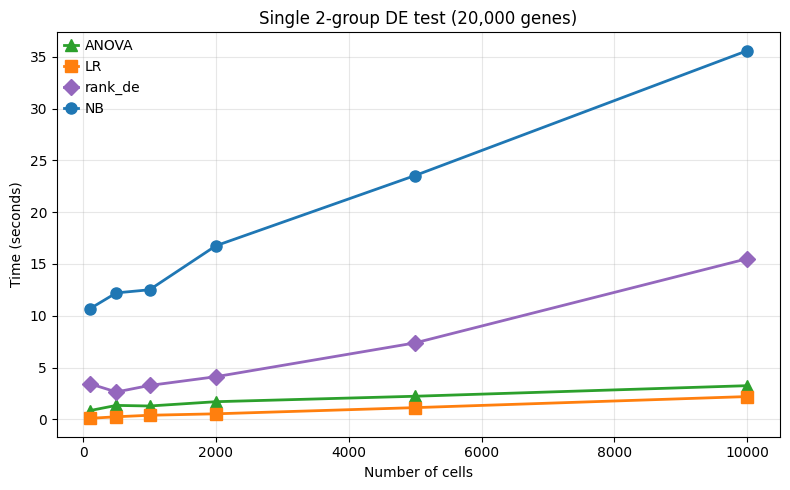

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"ANOVA": "#2ca02c", "LR": "#ff7f0e", "rank_de": "#9467bd", "NB": "#1f77b4"}
markers = {"ANOVA": "^", "LR": "s", "rank_de": "D", "NB": "o"}

for method in ["ANOVA", "LR", "rank_de", "NB"]:
    sub = sample_df[sample_df["method"] == method].sort_values("n_cells")
    ax.plot(sub["n_cells"], sub["time"], label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])

ax.set_xlabel("Number of cells")
ax.set_ylabel("Time (seconds)")
ax.set_title(f"Single 2-group DE test ({N_GENES:,} genes)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## 2. One-vs-all marker detection

Fixed: 20,000 genes, 100 cells per group. Vary number of groups: [5, 10, 20, 50].
Each group is tested against all remaining cells.

`rank_de` tests all groups in a single pass (vectorized AUROC). The other methods
require a loop of independent 1-vs-all tests.

In [6]:
N_CELLS_PER_GROUP = 100
group_counts = [5, 10, 20, 50]

marker_results = []


def run_onevsall_loop(adata, method, use_lognorm=False):
    """Run 1-vs-all DE for each group using a loop."""
    a = adata.copy()
    if use_lognorm:
        a.X = a.layers["lognorm"]
    for g in adata.obs["group"].unique():
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        _ = dx.tl.de(a, condition_key="is_group", reference="False", method=method, verbose=False)


def run_onevsall_nb(adata):
    """Run 1-vs-all NB for each group using a loop."""
    for g in adata.obs["group"].unique():
        a = adata.copy()
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        fit = dx.tl.nb_fit(a, condition_key="is_group", reference="False", verbose=False)
        _ = dx.tl.nb_test(a, fit, contrast="is_group[T.True]")


for n_groups in group_counts:
    n_total = n_groups * N_CELLS_PER_GROUP
    print(f"\n--- {n_groups} groups, {n_total:,} cells ---")
    adata = simulate_data(n_total, N_GENES, n_groups)

    # rank_de (all groups at once)
    t0 = time.time()
    _ = dx.tl.rank_de(adata, condition_key="group", verbose=False)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "rank_de", "time": t})
    print(f"  rank_de: {t:.1f}s")

    # ANOVA (1-vs-all loop)
    t0 = time.time()
    run_onevsall_loop(adata, "anova", use_lognorm=True)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "ANOVA", "time": t})
    print(f"  ANOVA:   {t:.1f}s")

    # LR (1-vs-all loop)
    t0 = time.time()
    run_onevsall_loop(adata, "lr", use_lognorm=True)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "LR", "time": t})
    print(f"  LR:      {t:.1f}s")

    # NB (1-vs-all loop)
    t0 = time.time()
    run_onevsall_nb(adata)
    t = time.time() - t0
    marker_results.append({"n_groups": n_groups, "method": "NB", "time": t})
    print(f"  NB:      {t:.1f}s")

marker_df = pd.DataFrame(marker_results)


--- 5 groups, 500 cells ---


E0420 16:34:46.665096 2965506 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[512,5]{1,0} fusion(select_n.0, one_hot.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0420 16:34:46.665198 2965506 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[500,512]{1,0} parameter(0)
  parameter_1 = f32[500,5]{1,0} parameter(1)
  ROOT dot_general.0 = f32[512,5]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={0}, rhs_contracting_dims={0}, backend_config={"sizes":["128"]}
}


  rank_de: 4.2s


  ANOVA:   1.7s


  LR:      1.7s


...

E0420 16:39:27.185308 2965514 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[16,512,50]{2,1,0} fusion(select_n.0, one_hot.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["1","64","32"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0420 16:39:27.185431 2965514 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[5000,512]{1,0} parameter(0)
  constant = f32[] constant(0)
  pad = f32[5056,512]{1,0} pad(parameter_0, constant), padding=0_56x0_0
  bitcast = f32[16,316,512]{2,1,0} bitcast(pad)
  parameter_1 = f32[5000,50]{1,0} parameter(1)
  constant_1 = f32[] constant(0

  rank_de: 9.0s


  ANOVA:   56.0s


  LR:      57.9s


  NB:      490.7s


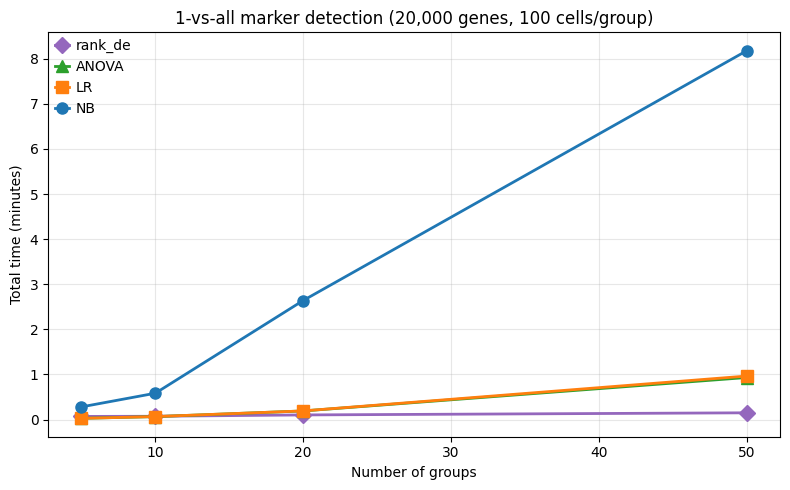

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for method in ["rank_de", "ANOVA", "LR", "NB"]:
    sub = marker_df[marker_df["method"] == method].sort_values("n_groups")
    ax.plot(sub["n_groups"], sub["time"] / 60, label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])

ax.set_xlabel("Number of groups")
ax.set_ylabel("Total time (minutes)")
ax.set_title(f"1-vs-all marker detection ({N_GENES:,} genes, {N_CELLS_PER_GROUP} cells/group)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## 3. Pairwise (1-vs-1) comparisons

Fixed: 20,000 genes, 200 cells per group. Vary number of groups: [3, 5, 10, 15].
For each pair of groups, run a DE test on the subset of cells from those two groups.
Number of pairwise tests = n_groups * (n_groups - 1) / 2.

`rank_de` does not natively support pairwise mode, so all methods loop over pairs.

In [8]:
from itertools import combinations

N_CELLS_PER_GROUP_PW = 200
group_counts_pw = [3, 5, 10, 15]

pairwise_results = []

for n_groups in group_counts_pw:
    n_total = n_groups * N_CELLS_PER_GROUP_PW
    n_pairs = n_groups * (n_groups - 1) // 2
    print(f"\n--- {n_groups} groups, {n_pairs} pairs, {n_total:,} cells ---")
    adata = simulate_data(n_total, N_GENES, n_groups)
    pairs = list(combinations(sorted(adata.obs["group"].unique()), 2))

    for method_name, method, use_ln in [("ANOVA", "anova", True), ("LR", "lr", True)]:
        t0 = time.time()
        for g1, g2 in pairs:
            mask = adata.obs["group"].isin([g1, g2])
            a = adata[mask].copy()
            if use_ln:
                a.X = a.layers["lognorm"]
            _ = dx.tl.de(a, condition_key="group", reference=g1, method=method, verbose=False)
        t = time.time() - t0
        pairwise_results.append({"n_groups": n_groups, "n_pairs": n_pairs, "method": method_name, "time": t})
        print(f"  {method_name:8s}: {t:.1f}s ({t/n_pairs:.2f}s/pair)")

    # rank_de (loop over pairs)
    t0 = time.time()
    for g1, g2 in pairs:
        mask = adata.obs["group"].isin([g1, g2])
        a = adata[mask].copy()
        _ = dx.tl.rank_de(a, condition_key="group", verbose=False)
    t = time.time() - t0
    pairwise_results.append({"n_groups": n_groups, "n_pairs": n_pairs, "method": "rank_de", "time": t})
    print(f"  rank_de:  {t:.1f}s ({t/n_pairs:.2f}s/pair)")

    # NB (loop over pairs)
    t0 = time.time()
    for g1, g2 in pairs:
        mask = adata.obs["group"].isin([g1, g2])
        a = adata[mask].copy()
        fit = dx.tl.nb_fit(a, condition_key="group", reference=g1, verbose=False)
        contrasts = [c for c in fit.design_column_names if c != "Intercept"]
        _ = dx.tl.nb_test(a, fit, contrast=contrasts[0])
    t = time.time() - t0
    pairwise_results.append({"n_groups": n_groups, "n_pairs": n_pairs, "method": "NB", "time": t})
    print(f"  NB:       {t:.1f}s ({t/n_pairs:.2f}s/pair)")

pairwise_df = pd.DataFrame(pairwise_results)


--- 3 groups, 3 pairs, 600 cells ---


  ANOVA   : 2.3s (0.77s/pair)


  LR      : 1.6s (0.52s/pair)


E0420 16:49:42.930360 2965543 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[512,2]{1,0} fusion(select_n.0, one_hot.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"2","output_tiles":[{"sizes":["64","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0420 16:49:42.930516 2965543 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[400,512]{1,0} parameter(0)
  parameter_1 = f32[400,2]{1,0} parameter(1)
  ROOT dot_general.0 = f32[512,2]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={0}, rhs_contracting_dims={0}, backend_config={"sizes":["128"]}
}


  rank_de:  5.8s (1.94s/pair)


...

  NB:       142.3s (3.16s/pair)

--- 15 groups, 105 pairs, 3,000 cells ---


  ANOVA   : 51.2s (0.49s/pair)


  LR      : 52.9s (0.50s/pair)


  rank_de:  167.7s (1.60s/pair)


  NB:       331.7s (3.16s/pair)


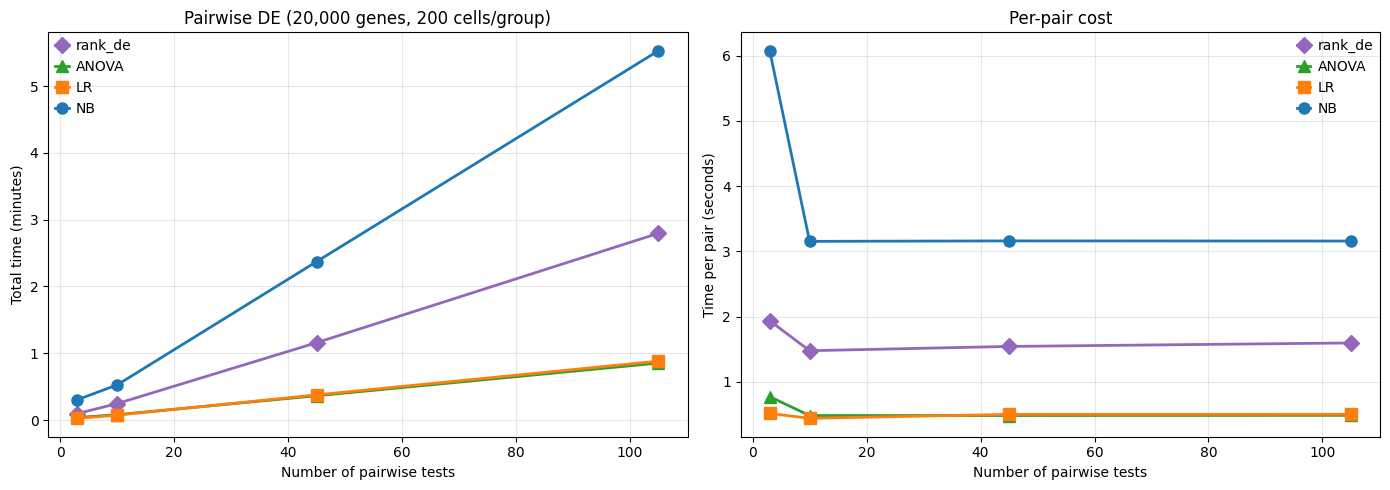

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total time vs number of pairs
ax = axes[0]
for method in ["rank_de", "ANOVA", "LR", "NB"]:
    sub = pairwise_df[pairwise_df["method"] == method].sort_values("n_pairs")
    ax.plot(sub["n_pairs"], sub["time"] / 60, label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])
ax.set_xlabel("Number of pairwise tests")
ax.set_ylabel("Total time (minutes)")
ax.set_title(f"Pairwise DE ({N_GENES:,} genes, {N_CELLS_PER_GROUP_PW} cells/group)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: time per pair
ax = axes[1]
for method in ["rank_de", "ANOVA", "LR", "NB"]:
    sub = pairwise_df[pairwise_df["method"] == method].sort_values("n_pairs")
    ax.plot(sub["n_pairs"], sub["time"] / sub["n_pairs"], label=method, linewidth=2, markersize=8,
            color=colors[method], marker=markers[method])
ax.set_xlabel("Number of pairwise tests")
ax.set_ylabel("Time per pair (seconds)")
ax.set_title("Per-pair cost")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

## Summary

| Scenario | Recommended method | Why |
|----------|-------------------|-----|
| Quick marker screening | `rank_de` | Tests all groups in one pass, scales to hundreds of clusters |
| Pseudobulk DE (counts) | `nb_fit` + `nb_test` | Proper count model with dispersion shrinkage |
| Lognorm continuous data | `de(method="anova")` | Fast closed-form F-test |
| Binary / covariate control | `de(method="lr")` | Logistic regression with flexible design |
| Many pairwise comparisons | `rank_de` or `de(method="anova")` | Low per-test overhead |

**Joint vs separate NB models**: Use separate 2-coefficient fits for single-cell data
(many cells per group, fast, parallelizable). Use a joint model for pseudobulk with
few replicates per condition, where pooling dispersions across all samples matters.

## 4. NB joint model vs separate fits

For count-based DE with multiple groups, there are two strategies:

- **Joint model**: fit one NB GLM with all groups as coefficients, then test each group via contrasts. Dispersion is estimated from all samples (better for small groups). Cost: O(n_coef³) per gene.
- **Separate fits**: fit independent 2-coefficient models (group-vs-rest or group-vs-control). Each fit is fast but dispersion is estimated per subset.

We compare both for 1-vs-all marker detection with varying group counts.

In [10]:
joint_group_counts = [5, 10, 20, 50]
N_CELLS_PER_GROUP_JV = 100

joint_results = []

for n_groups in joint_group_counts:
    n_total = n_groups * N_CELLS_PER_GROUP_JV
    print(f"\n--- {n_groups} groups, {n_total:,} cells ---")
    adata = simulate_data(n_total, N_GENES, n_groups)

    # Joint model: fit once with all groups, test each via contrasts
    t0 = time.time()
    fit_joint = dx.tl.nb_fit(adata, condition_key="group", reference="g0", verbose=False)
    contrasts = [c for c in fit_joint.design_column_names if c != "Intercept"]
    for c in contrasts:
        _ = dx.tl.nb_test(adata, fit_joint, contrast=c)
    t_joint = time.time() - t0
    joint_results.append({"n_groups": n_groups, "strategy": "Joint model", "time": t_joint})
    print(f"  Joint ({n_groups} coefs, 1 fit + {len(contrasts)} tests): {t_joint:.1f}s")

    # Separate fits: one 2-coef model per group (1-vs-all)
    t0 = time.time()
    for g in adata.obs["group"].unique():
        a = adata.copy()
        a.obs["is_group"] = (a.obs["group"] == g).astype(str)
        fit_sep = dx.tl.nb_fit(a, condition_key="is_group", reference="False", verbose=False)
        _ = dx.tl.nb_test(a, fit_sep, contrast="is_group[T.True]")
    t_sep = time.time() - t0
    joint_results.append({"n_groups": n_groups, "strategy": "Separate fits", "time": t_sep})
    print(f"  Separate ({n_groups} x 2-coef fits):              {t_sep:.1f}s")
    print(f"  Ratio (joint/separate): {t_joint/t_sep:.2f}x")

joint_df = pd.DataFrame(joint_results)


--- 5 groups, 500 cells ---


  Joint (5 coefs, 1 fit + 4 tests): 12.8s


  Separate (5 x 2-coef fits):              16.9s
  Ratio (joint/separate): 0.75x

--- 10 groups, 1,000 cells ---


  Joint (10 coefs, 1 fit + 9 tests): 14.8s


  Separate (10 x 2-coef fits):              34.9s
  Ratio (joint/separate): 0.43x

--- 20 groups, 2,000 cells ---


  Joint (20 coefs, 1 fit + 19 tests): 29.4s


  Separate (20 x 2-coef fits):              161.8s
  Ratio (joint/separate): 0.18x

--- 50 groups, 5,000 cells ---


  Joint (50 coefs, 1 fit + 49 tests): 195.2s


  Separate (50 x 2-coef fits):              498.3s
  Ratio (joint/separate): 0.39x


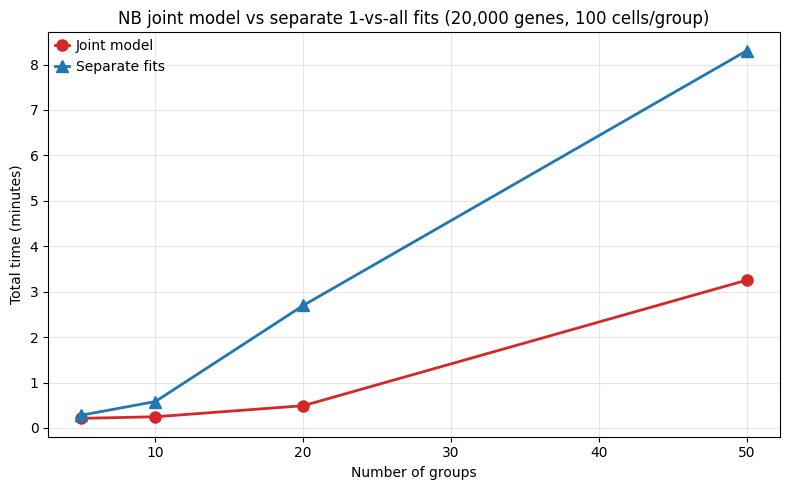

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for strategy, style in [("Joint model", dict(color="#d62728", marker="o")),
                         ("Separate fits", dict(color="#1f77b4", marker="^"))]:
    sub = joint_df[joint_df["strategy"] == strategy].sort_values("n_groups")
    ax.plot(sub["n_groups"], sub["time"] / 60, label=strategy, linewidth=2, markersize=8, **style)

ax.set_xlabel("Number of groups")
ax.set_ylabel("Total time (minutes)")
ax.set_title(f"NB joint model vs separate 1-vs-all fits ({N_GENES:,} genes, {N_CELLS_PER_GROUP_JV} cells/group)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()